# Бібліотеки

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Датасет MNIST і нормалізація

Для тренування завантажую датасет MNIST. Кожен елемент датасету є зображенням 28 на 28 пікселів з кольоровою схемою віл 0 до 255. Нормалізую, щоб кожен піксель приймав значення від 0 до 1

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = tf.keras.utils.normalize(x_train, axis=1)
x_test = tf.keras.utils.normalize(x_test, axis=1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Модель, тренування і перевірка

In [4]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=(28,28)))
model.add(tf.keras.layers.Dense(32, activation='relu'))
model.add(tf.keras.layers.Dense(16, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
model.compile(
 optimizer='adam',
 loss='sparse_categorical_crossentropy',
 metrics=['accuracy']
)
history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7723 - loss: 0.7620 - val_accuracy: 0.9267 - val_loss: 0.2655
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9300 - loss: 0.2428 - val_accuracy: 0.9428 - val_loss: 0.1962
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9463 - loss: 0.1838 - val_accuracy: 0.9443 - val_loss: 0.1853
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9557 - loss: 0.1498 - val_accuracy: 0.9533 - val_loss: 0.1591
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9601 - loss: 0.1311 - val_accuracy: 0.9546 - val_loss: 0.1508
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9652 - loss: 0.1173 - val_accuracy: 0.9580 - val_loss: 0.1416
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9692 - loss: 0.1030 - val_accuracy: 0.9584 - val_loss: 0.1435
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9703 - loss: 0.0969 

Графік втрат і точності

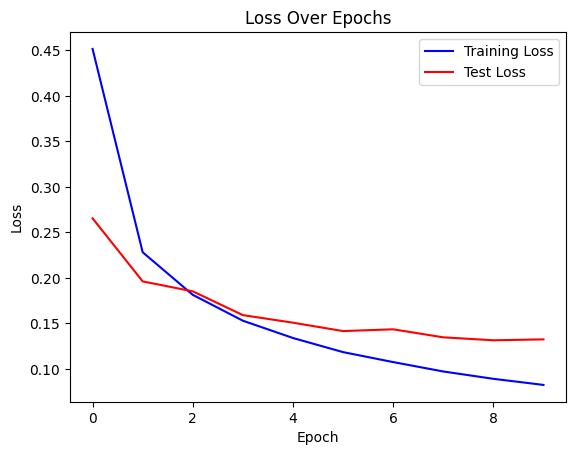

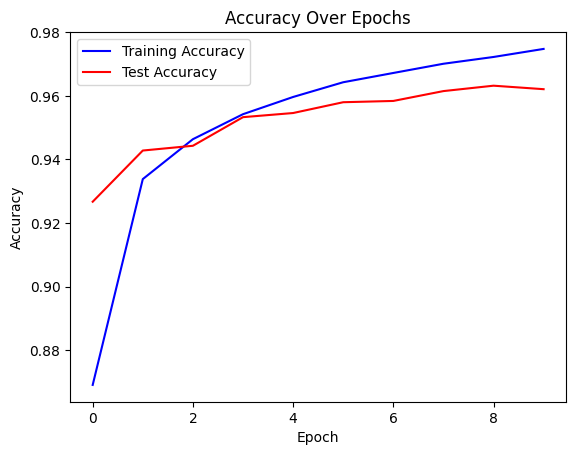

In [6]:
plt.plot(history.history['loss'], color='b', label='Training Loss')
plt.plot(history.history['val_loss'], color='r', label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Over Epochs')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], color='b', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], color='r', label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Over Epochs')
plt.legend()
plt.show()

Остаточна перевірка на тестових даних

In [7]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_accuracy}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9585 - loss: 0.1524
Test Loss: 0.13246463239192963
Test Accuracy: 0.9621000289916992


Приклад передбачення

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step


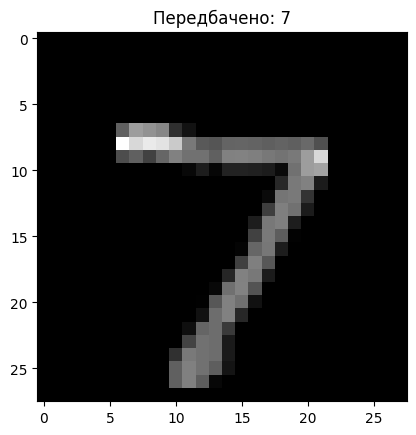

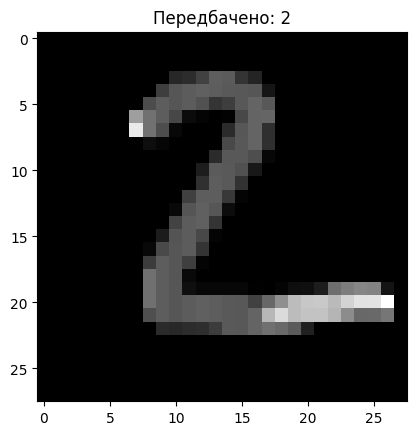

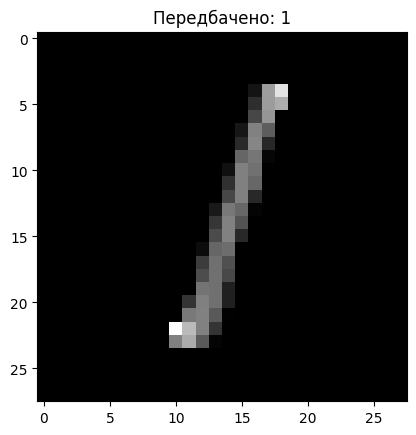

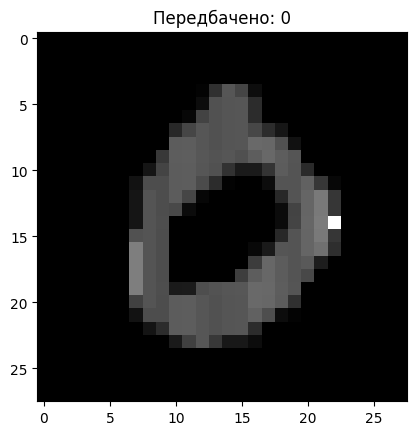

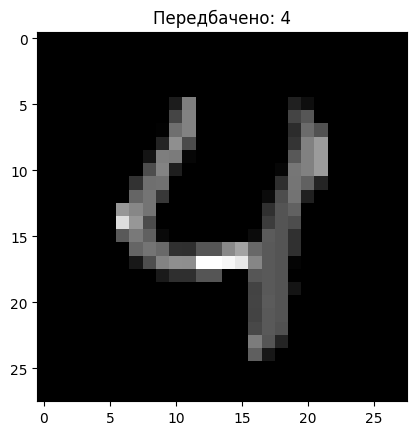

In [8]:
predictions = model.predict(x_test[:5])
for i in range(5):
 plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
 plt.title(f"Передбачено: {np.argmax(predictions[i])}")
 plt.show()